# Objective of this script

Currently the data is organized such that each day we have one file for each city, which contains the forecasts for the next X days. It would be much better to have one large file containing the full data and meta data:

**Meta data**
- Location name
- Coordinates
- Date & time when forecast was made
- Date & time for which the forecast is made

**Data**
- Measurable weather data

Import Python packages

In [1]:
import json
import os

import numpy as np
import pandas as pd

Create the target data file that will contain the data in the new format

In [2]:
target_data_file_name = "forecasting_data.csv"
forecasting_data = pd.DataFrame()

The city location and weather metrics are stored in the user config file.

In [3]:
CONFIG_FILE = "../data/user/.fue_config.json"
with open(CONFIG_FILE) as configfile:
    config_dict = json.load(configfile)
cities = config_dict["cities"]
metrics = config_dict["metrics"]

Update columns of target data file

In [4]:
columns = [
    "location name",
    "latitude",
    "longitude",
    "forecasted_on",
    "forecast_for"]
# Now add physical weather metrics to the column list
columns = columns + metrics

Now we iterate through each file and in each file through each forecast and append the forecast to the forecasting_data DataFrame.

In [ ]:
RAW_DATA = "../data/raw/"
PROCESSED_DATA = "../data/processed"
files = os.listdir(RAW_DATA)
for file in files:

    # Read Data
    file_path = RAW_DATA + file
    df = pd.read_csv(file_path)

    # Extract meta data
    city_name, date_str = file[:-4].split("_") # filename looks like: aachen_20260601.csv
    lat = cities[city_name]["lat"]
    lon = cities[city_name]["lon"]
    # assume that previous forecasts were downloaded roughly around midday
    forecasted_on = pd.to_datetime(f"{date_str}12", format="%Y%m%d%H")

    # Create new 1-row DataFrame, which we can then append to the global DataFrame.
    new_row = {}
    new_row["location_name"] = city_name
    new_row["latitude"] = lat
    new_row["longitude"] = lon
    new_row["forecasted_on"] = forecasted_on

    for row in df.iterrows():
        data_point = row[1] # First item is just an index, the second item contains the data
        # assume that previous forecasts were downloaded roughly around midday
        new_row["forecast_for"] = pd.to_datetime(f"{data_point["date"]}23:59:59", format="%Y-%m-%d%H:%M:%S")
        for metric in metrics:
            try:
                new_row[metric] = data_point[metric]
            except Exception as e:
                new_row[metric] = np.nan
                print(f"Couldn't find entry for {metric} in new_row dictionary. Error message: {e}")
        forecasting_data = pd.concat([forecasting_data, pd.DataFrame([new_row])], ignore_index=True)

In [6]:
forecasting_data.sort_values(["location_name", "forecasted_on"])

,location_name,latitude,longitude,forecasted_on,forecast_for,temperature_2m_max,temperature_2m_min,precipitation_sum,sunshine_duration,wind_direction_10m_dominant,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,precipitation_probability_mean
2652,aachen,50.7753,6.0839,2026-04-15 12:00:00,2026-04-15 23:59:59,19.126,7.826,0.0,44919.938,197.130810,12.240000,24.119999,8.340000,1.041667
2653,aachen,50.7753,6.0839,2026-04-15 12:00:00,2026-04-16 23:59:59,18.526,11.926,0.1,35147.580,247.859120,12.959999,25.919998,8.400000,10.791667
2654,aachen,50.7753,6.0839,2026-04-15 12:00:00,2026-04-17 23:59:59,20.376,12.776,0.0,42178.040,262.144130,6.840000,19.080000,4.050000,0.000000
2655,aachen,50.7753,6.0839,2026-04-15 12:00:00,2026-04-18 23:59:59,17.950,10.000,7.1,41540.830,247.764850,10.742848,27.359999,6.400315,22.500000
2656,aachen,50.7753,6.0839,2026-04-15 12:00:00,2026-04-19 23:59:59,13.900,7.800,4.2,48234.727,338.250900,15.188417,37.440000,11.015160,35.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,zurich,47.3769,8.5472,2026-06-16 12:00:00,2026-06-25 23:59:59,31.950,20.850,0.0,56573.168,0.622741,8.396570,28.080000,4.966198,10.208333
677,zurich,47.3769,8.5472,2026-06-16 12:00:00,2026-06-26 23:59:59,31.800,20.950,0.0,56386.074,46.253180,9.984729,34.200000,7.959393,8.708333
678,zurich,47.3769,8.5472,2026-06-16 12:00:00,2026-06-27 23:59:59,32.850,21.700,0.0,56587.156,51.724316,9.840914,25.560000,6.506129,8.333333
679,zurich,47.3769,8.5472,2026-06-16 12:00:00,2026-06-28 23:59:59,34.950,22.650,0.0,56555.960,357.604130,8.209263,23.400000,4.425022,7.166666


Let's see how many ground truth values we have and how many predictions

In [ ]:
labels = 0
trainings = 0
for row in forecasting_data.iterrows():
    data = row[1]
    f_on = data["forecasted_on"]
    f_for = data["forecast_for"]
    if (f_on + pd.Timedelta(hours=12) < f_for):
        trainings += 1
    if (f_on + pd.Timedelta(hours=12) >= f_for):
        labels += 1
print(trainings, labels)

2056 657


Store the compact data frame as a csv

In [8]:
FILE_NAME = "compact_forecast_data.csv"
FILE_PATH = "../data/processed/"

# check if there is already a compact data file and if so, join them without duplicates
PATH = os.path.join(FILE_PATH, FILE_NAME)
if os.path.exists(PATH):
    existing_data = pd.read_csv(PATH, parse_dates=['forecasted_on', 'forecast_for'])
    existing_count = len(existing_data)
    combined_data = pd.concat([existing_data, forecasting_data], ignore_index=True)
    combined_data = combined_data.drop_duplicates(
        subset=['location_name', 'forecasted_on', 'forecast_for'],
        keep='last'
    )
    entries_added = len(combined_data) - existing_count
    print(f"Added {entries_added} new entries to the dataset")
    combined_data.to_csv(PATH, index=False)
else:
    forecasting_data.to_csv(PATH, index=False)

Added 0 new entries to the dataset


Index(['latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_min',
       'precipitation_sum', 'sunshine_duration', 'wind_direction_10m_dominant',
       'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_speed_10m_mean',
       'precipitation_probability_mean'],
      dtype='str')


,latitude,longitude,temperature_2m_max,temperature_2m_min,precipitation_sum,sunshine_duration,wind_direction_10m_dominant,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,precipitation_probability_mean
latitude,1.000000,0.516077,-0.437595,-0.419412,0.202123,-0.152385,0.277190,0.085219,0.008081,0.313085,0.337900
longitude,0.516077,1.000000,-0.151348,-0.214388,0.103461,-0.078970,0.249949,-0.187603,-0.103043,-0.116841,0.129853
temperature_2m_max,-0.437595,-0.151348,1.000000,0.867185,-0.262298,0.510066,-0.087618,-0.280990,-0.065481,-0.385880,-0.405213
temperature_2m_min,-0.419412,-0.214388,0.867185,1.000000,-0.112361,0.311556,-0.037508,-0.105215,0.100705,-0.197516,-0.191690
precipitation_sum,0.202123,0.103461,-0.262298,-0.112361,1.000000,-0.484908,0.146848,0.156811,0.146147,0.139166,0.635045
sunshine_duration,-0.152385,-0.078970,0.510066,0.311556,-0.484908,1.000000,-0.116330,-0.251739,-0.104575,-0.211303,-0.572481
wind_direction_10m_dominant,0.277190,0.249949,-0.087618,-0.037508,0.146848,-0.116330,1.000000,0.150707,0.179229,0.161531,0.222558
wind_speed_10m_max,0.085219,-0.187603,-0.280990,-0.105215,0.156811,-0.251739,0.150707,1.000000,0.824570,0.849644,0.284013
wind_gusts_10m_max,0.008081,-0.103043,-0.065481,0.100705,0.146147,-0.104575,0.179229,0.824570,1.000000,0.701263,0.226989
wind_speed_10m_mean,0.313085,-0.116841,-0.385880,-0.197516,0.139166,-0.211303,0.161531,0.849644,0.701263,1.000000,0.328639


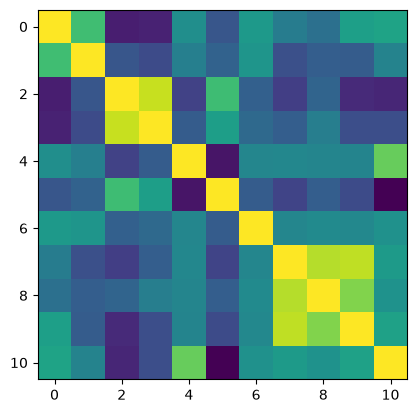

In [13]:
import matplotlib.pyplot as plt

corr_matrix = forecasting_data.select_dtypes("number").corr()
print(forecasting_data.select_dtypes("number").columns)
plt.imshow(corr_matrix)
corr_matrix